# OK MAYBE WE GO WITH THIS ONE

# Image Colorization — cGAN (LAB color space)

**Pipeline:** L-channel → Generator (U-Net) → predicted AB → merge with L → RGB  
**Architecture:** conditional GAN — Generator + PatchGAN Discriminator  
**Loss:** Generator = L1 + adversarial | Discriminator = BCE  

---
### Why cGAN over plain U-Net?
- U-Net with MSE tends to produce desaturated, grayish colors (averages over uncertainty)
- The Discriminator forces the Generator to produce *realistic* color distributions
- L1 loss keeps the output close to ground truth, adversarial loss adds vibrancy

## 0. Imports

In [3]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from skimage import color as skcolor
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # This fixes the OpenMP kernel crash!

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 NVIDIA GPU Detected! Using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍏 Apple Silicon Detected! Using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print("🎮 AMD/Windows GPU Detected! Using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print("🐌 No recognized GPU found. Falling back to CPU. (This will be slow!)")

🎮 AMD/Windows GPU Detected! Using DirectML.


## 1. Config

In [4]:
ROOT_DIR   = 'data/images'  # folder with color images
IMG_SIZE   = 128
LIMIT      = 2_000          # set None to use all images
BATCH      = 16             # smaller batch works better for GAN stability
WORKERS    = 0              # 0 on Windows
EPOCHS     = 10
LR         = 2e-4
LAMBDA_L1  = 100            # weight of L1 loss vs adversarial loss
SAVE_EVERY = 2              # save sample grid every N epochs

## 2. Dataset (LAB)
Returns `L` in `[-1, 1]` and `ab` in `[-1, 1]`.

In [5]:
class LabDataset(Dataset):
    def __init__(self, root_dir, size=128, limit=None):
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        paths = [f for f in os.listdir(root_dir)
                 if os.path.splitext(f)[1].lower() in exts]
        if limit:
            paths = paths[:limit]
        self.paths = [os.path.join(root_dir, p) for p in paths]
        self.size  = size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert('RGB')
        img    = img.resize((self.size, self.size), Image.BILINEAR)
        rgb_np = np.array(img, dtype=np.float32) / 255.0
        lab    = skcolor.rgb2lab(rgb_np).astype(np.float32)

        L_t  = torch.from_numpy(lab[:,:,0:1].transpose(2,0,1)) / 50.0 - 1.0  # [-1, 1]
        ab_t = torch.from_numpy(lab[:,:,1:3].transpose(2,0,1)) / 110.0        # [-1, 1]
        return L_t, ab_t


dataset = LabDataset(ROOT_DIR, size=IMG_SIZE, limit=LIMIT)
loader  = DataLoader(dataset, batch_size=BATCH, shuffle=True,
                     num_workers=WORKERS, pin_memory=(device.type == 'cuda'))
print(f'Images : {len(dataset)}  |  Batches : {len(loader)}')

Images : 2000  |  Batches : 125


## 3. Helper functions — LAB ↔ RGB

In [6]:
def lab_to_rgb(L_t, ab_t):
    """Convert L [1,H,W] and ab [2,H,W] tensors (both in [-1,1]) to RGB numpy [H,W,3]."""
    L  = (L_t.squeeze().numpy()   + 1.0) * 50.0
    ab = ab_t.permute(1,2,0).numpy() * 110.0
    lab = np.concatenate([L[:,:,None], ab], axis=2)
    return skcolor.lab2rgb(lab.astype(np.float64)).clip(0, 1)


def mse_to_psnr(mse):
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

## 4. Preview — dataset sample

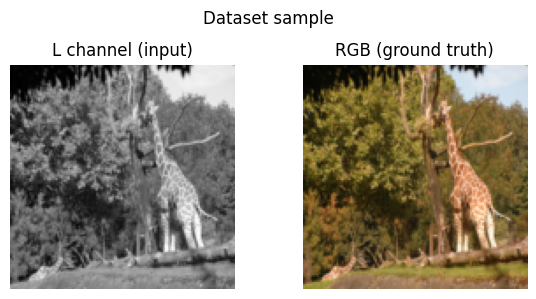

In [7]:
L_t, ab_t = dataset[0]
gray_np = (L_t.squeeze().numpy() + 1.0) / 2.0
rgb_np  = lab_to_rgb(L_t, ab_t)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(gray_np, cmap='gray'); axes[0].set_title('L channel (input)')
axes[1].imshow(rgb_np);               axes[1].set_title('RGB (ground truth)')
for ax in axes: ax.axis('off')
plt.suptitle('Dataset sample', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Generator — U-Net
Input: `[1, H, W]` (L channel)  
Output: `[2, H, W]` (AB channels), activated with `tanh`

In [8]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = conv_block(1,   64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.mid  = conv_block(256, 512)
        # Decoder
        self.up3  = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128,  64, 2, 2)
        self.dec1 = conv_block(128,  64)
        # Output — 2 AB channels
        self.out  = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        m  = self.mid(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(m),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.tanh(self.out(d1))

G = Generator().to(device)
print(f'Generator parameters: {sum(p.numel() for p in G.parameters()):,}')

Generator parameters: 7,701,890


## 6. Discriminator — PatchGAN
Classifies overlapping 70×70 patches as real/fake.  
Input: concatenation of L + AB → `[3, H, W]`  
Output: feature map of real/fake scores (not a single scalar)

In [9]:
def d_block(in_c, out_c, stride=2, bn=True):
    layers = [nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1, bias=not bn)]
    if bn:
        layers.append(nn.BatchNorm2d(out_c))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

class Discriminator(nn.Module):
    """PatchGAN — judges realness of image patches, not the full image."""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            d_block(3,   64,  stride=2, bn=False),  # L + AB = 3 channels
            d_block(64,  128, stride=2),
            d_block(128, 256, stride=2),
            d_block(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, padding=1),        # patch scores
        )

    def forward(self, L, ab):
        x = torch.cat([L, ab], dim=1)   # condition on L
        return self.model(x)

D = Discriminator().to(device)
print(f'Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}')

Discriminator parameters: 2,765,633


## 7. Training

**Each iteration:**
1. Train D: real pair `(L, ab_real)` → 1, fake pair `(L, ab_pred)` → 0  
2. Train G: fool D + minimize L1 distance to ground truth  

`loss_G = adversarial_loss + λ * L1_loss`

In [10]:
criterion_bce = nn.BCEWithLogitsLoss()
criterion_l1  = nn.L1Loss()

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

history = {'loss_G': [], 'loss_D': [], 'psnr': []}

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    sum_G = sum_D = sum_mse = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=True)
    for L_t, ab_real in pbar:
        L_t, ab_real = L_t.to(device), ab_real.to(device)
        bs = L_t.size(0)

        real_label = torch.ones (D(L_t, ab_real).shape, device=device)
        fake_label = torch.zeros(real_label.shape,       device=device)

        # ── Discriminator ──────────────────────────────────────────────
        ab_pred = G(L_t).detach()   # detach: don't backprop through G yet

        loss_D_real = criterion_bce(D(L_t, ab_real), real_label)
        loss_D_fake = criterion_bce(D(L_t, ab_pred), fake_label)
        loss_D = (loss_D_real + loss_D_fake) * 0.5

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ── Generator ──────────────────────────────────────────────────
        ab_pred = G(L_t)   # fresh forward pass

        loss_G_adv = criterion_bce(D(L_t, ab_pred), real_label)   # fool D
        loss_G_l1  = criterion_l1(ab_pred, ab_real) * LAMBDA_L1   # stay close
        loss_G     = loss_G_adv + loss_G_l1

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # track metrics
        mse = ((ab_pred.detach() - ab_real) ** 2).mean().item()
        sum_G   += loss_G.item()
        sum_D   += loss_D.item()
        sum_mse += mse
        pbar.set_postfix(G=f'{loss_G.item():.3f}', D=f'{loss_D.item():.3f}')

    n     = len(loader)
    avg_G = sum_G   / n
    avg_D = sum_D   / n
    psnr  = mse_to_psnr(sum_mse / n)
    history['loss_G'].append(avg_G)
    history['loss_D'].append(avg_D)
    history['psnr'].append(psnr)
    print(f'  => G={avg_G:.4f}  D={avg_D:.4f}  PSNR={psnr:.2f} dB')

torch.save(G.state_dict(), 'generator_lab.pth')
torch.save(D.state_dict(), 'discriminator_lab.pth')
print('\nModels saved → generator_lab.pth / discriminator_lab.pth')

Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

c:\Users\axela\anaconda3\envs\torch_new\lib\site-packages\torch\nn\functional.py:3244: UserWarning: The operator 'aten::log_sigmoid_forward' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch.binary_cross_entropy_with_logits(input, target, weight, pos_weight, reduction_enum)


  => G=12.3067  D=0.5096  PSNR=15.75 dB


Epoch 2/10:   0%|          | 0/125 [00:00<?, ?it/s]

  => G=11.8863  D=0.4775  PSNR=16.17 dB


...

  => G=11.9609  D=0.4902  PSNR=16.11 dB


Epoch 9/10:   0%|          | 0/125 [00:00<?, ?it/s]

  => G=12.4276  D=0.4131  PSNR=16.14 dB


Epoch 10/10:   0%|          | 0/125 [00:00<?, ?it/s]

  => G=11.2351  D=0.5789  PSNR=16.45 dB

Models saved → generator_lab.pth / discriminator_lab.pth


## 8. Training curves

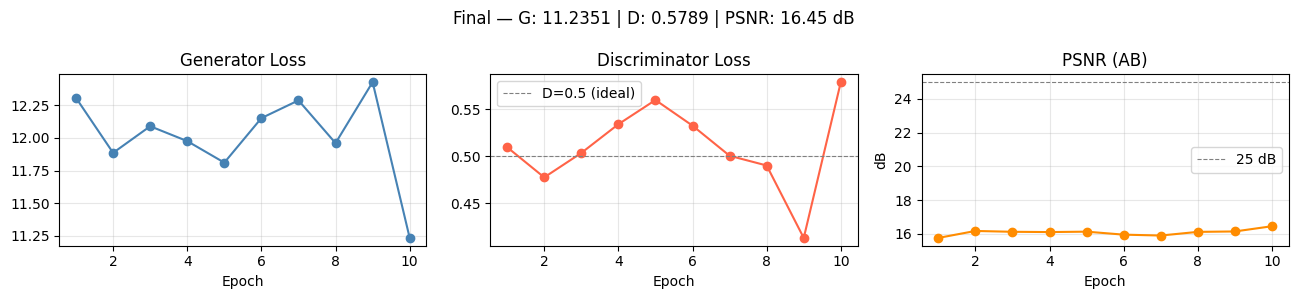

In [11]:
ep = range(1, EPOCHS + 1)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3))

ax1.plot(ep, history['loss_G'], marker='o', color='steelblue')
ax1.set_title('Generator Loss'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)

ax2.plot(ep, history['loss_D'], marker='o', color='tomato')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='D=0.5 (ideal)')
ax2.set_title('Discriminator Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

ax3.plot(ep, history['psnr'], marker='o', color='darkorange')
ax3.axhline(25, color='gray', linestyle='--', linewidth=0.8, label='25 dB')
ax3.set_title('PSNR (AB)'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('dB')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle(f'Final — G: {history["loss_G"][-1]:.4f} | D: {history["loss_D"][-1]:.4f} | PSNR: {history["psnr"][-1]:.2f} dB')
plt.tight_layout()
plt.show()

## 9. Results — sample grid

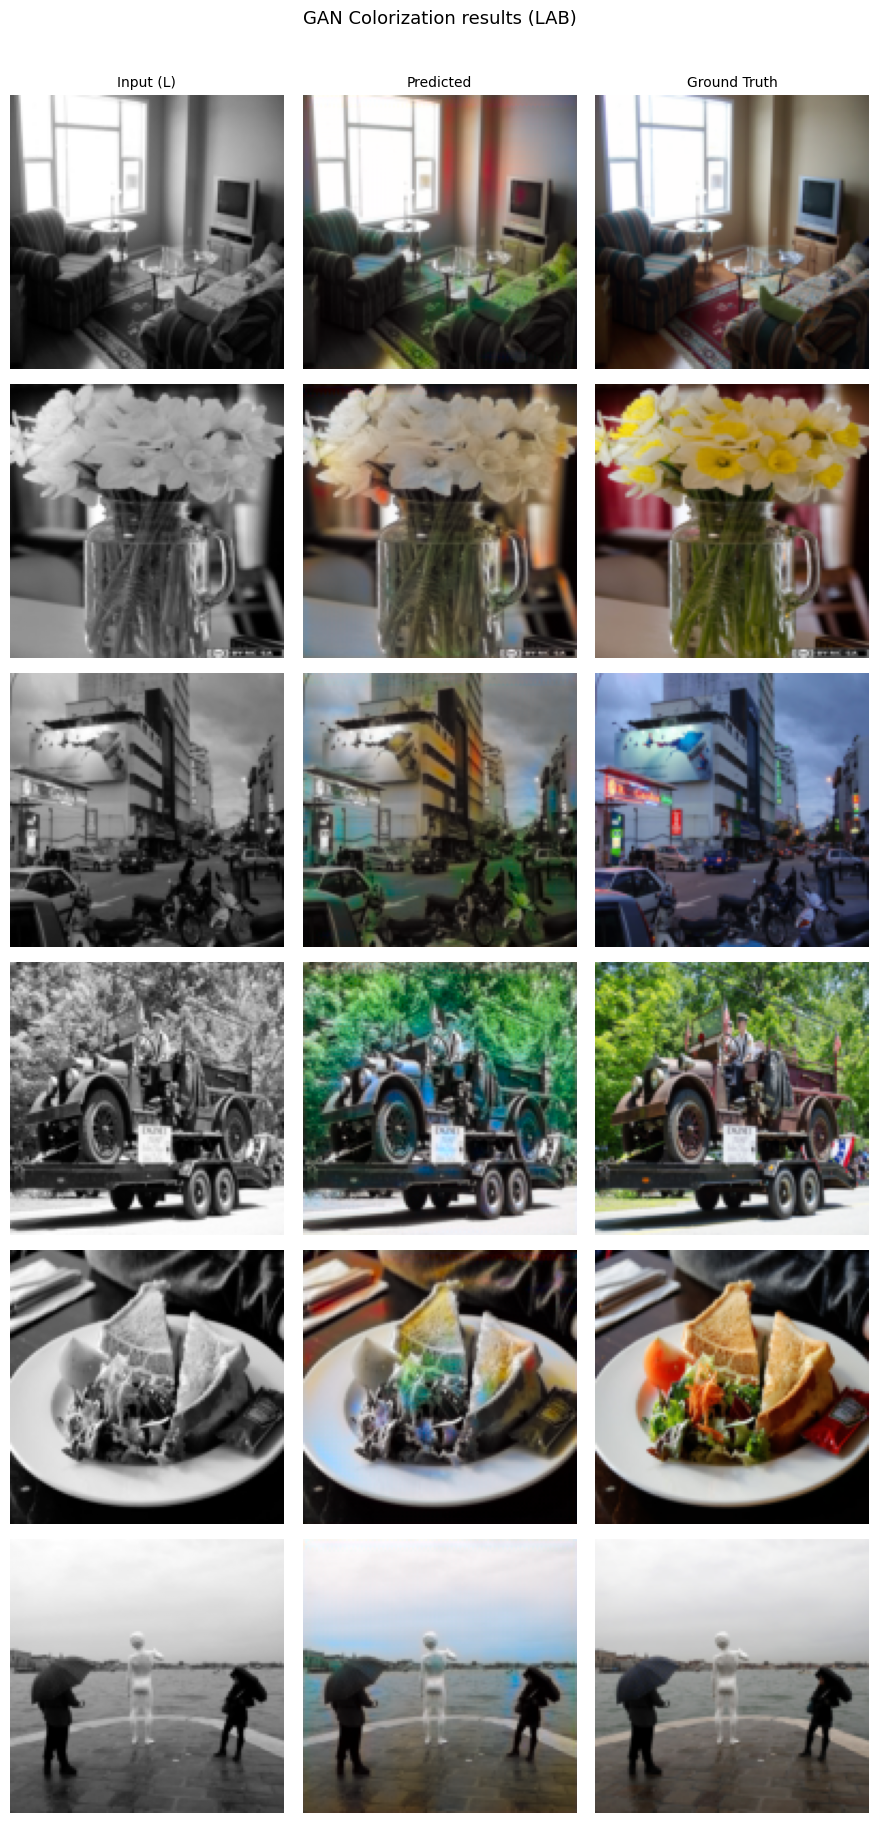

Saved → result_gan.png


In [12]:
def show_grid(model, dataset, n=6, indices=None):
    if indices is None:
        indices = random.sample(range(len(dataset)), min(n, len(dataset)))

    model.eval()
    fig, axes = plt.subplots(len(indices), 3,
                             figsize=(9, 3 * len(indices)), squeeze=False)

    for row, idx in enumerate(indices):
        L_t, ab_t = dataset[idx]
        with torch.no_grad():
            pred_ab = model(L_t.unsqueeze(0).to(device)).squeeze(0).cpu()

        gray_np  = (L_t.squeeze().numpy() + 1.0) / 2.0
        pred_rgb = lab_to_rgb(L_t, pred_ab)
        true_rgb = lab_to_rgb(L_t, ab_t)

        mse  = float(((pred_ab - ab_t) ** 2).mean())
        psnr = mse_to_psnr(mse)

        axes[row][0].imshow(gray_np, cmap='gray')
        axes[row][1].imshow(pred_rgb)
        axes[row][2].imshow(true_rgb)
        axes[row][0].set_ylabel(f'#{idx}  PSNR={psnr:.1f}dB', fontsize=8)
        for ax in axes[row]: ax.axis('off')

    axes[0][0].set_title('Input (L)',    fontsize=10)
    axes[0][1].set_title('Predicted',    fontsize=10)
    axes[0][2].set_title('Ground Truth', fontsize=10)
    plt.suptitle('GAN Colorization results (LAB)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('result_gan.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved → result_gan.png')


show_grid(G, dataset, n=6)

## 10. Load saved models

In [13]:
# G = Generator().to(device)
# G.load_state_dict(torch.load('generator_lab.pth', map_location=device))
# G.eval()
# print('Generator loaded')